# Temperatura de una placa que disipa calor por radiación

Una placa de acero de 20 × 20 cm con un componente caliente en el centro. En estado
estacionario la placa **conduce** calor hacia los bordes y además lo **radía** al
ambiente. La ley de Stefan-Boltzmann hace que el término radiativo vaya como `T⁴`,
y ahí aparece la no linealidad:

$$ -k\,d\,\nabla^2 T \;+\; 2\varepsilon\sigma\left(T^4 - T_{amb}^4\right) \;=\; q(x,y) $$

Con una malla de 50 × 50 hay **2 500 incógnitas**, así que el Jacobiano tendría
6 250 000 entradas. No lo vamos a construir: el método solo necesita multiplicar por
él, y ese producto se aproxima con una evaluación más de la función.

In [1]:
# Requisitos:  pip install numpy scipy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import LinearOperator, gmres

## Datos físicos y malla

In [2]:
n       = 50          # nodos interiores por lado  ->  n*n incógnitas
L       = 0.20        # lado de la placa [m]
k_cond  = 50.0        # conductividad del acero [W/(m·K)]
espesor = 0.005       # espesor de la placa [m]
emis    = 0.80        # emisividad
sigma   = 5.670e-8    # constante de Stefan-Boltzmann [W/(m²·K⁴)]
T_amb   = 300.0       # ambiente [K]
T_borde = 300.0       # bordes sujetos a 300 K

h = L / (n + 1)
x = np.linspace(0, L, n + 2)[1:-1]
X, Y = np.meshgrid(x, x, indexing="ij")

# foco de calor gaussiano en el centro (el componente caliente)
q = 3.0e5 * np.exp(-((X - L/2)**2 + (Y - L/2)**2) / (2 * 0.025**2))

print(f"incógnitas          : {n*n:,}")
print(f"entradas de J si la formáramos: {(n*n)**2:,}")

incógnitas          : 2,500
entradas de J si la formáramos: 6,250,000


## El residuo

In [3]:
def F(t):
    """Cuánto le falta a la placa para estar en equilibrio térmico."""
    T = t.reshape(n, n)
    Tb = np.full((n + 2, n + 2), T_borde)
    Tb[1:-1, 1:-1] = T
    lap = (Tb[:-2, 1:-1] + Tb[2:, 1:-1] + Tb[1:-1, :-2] + Tb[1:-1, 2:] - 4*T) / h**2
    r = -k_cond * espesor * lap + 2 * emis * sigma * (T**4 - T_amb**4) - q
    return (r * h**2 / (k_cond * espesor)).ravel()      # escalado a orden 1

## Precondicionador

La parte conductiva (el laplaciano) es casi todo el operador y es dispersa: se
factoriza una sola vez y se reutiliza en cada iteración.

In [4]:
def precondicionador():
    N = n * n
    e = np.ones(N)
    A = sp.diags([-e, -e, 4*e, -e, -e], [-n, -1, 0, 1, n], shape=(N, N), format="lil")
    for i in range(1, n):                 # cortar el acople entre filas de la malla
        A[i*n - 1, i*n] = 0
        A[i*n, i*n - 1] = 0
    lu = spla.splu(A.tocsc())
    return LinearOperator((N, N), matvec=lu.solve, dtype=float)

M = precondicionador()

## Newton-Krylov sin construir el Jacobiano

In [5]:
def resolver(precond=None, max_iter=40, tol=1e-9):
    t = np.full(n * n, T_borde)
    cuenta = {"F": 0, "Jv": 0}

    def evaluar(z):
        cuenta["F"] += 1
        return F(z)

    Ft = evaluar(t)
    residuos = [np.linalg.norm(Ft)]

    for it in range(max_iter):
        nF = np.linalg.norm(Ft)
        if nF <= tol * max(residuos[0], 1.0):
            break

        def por_vector(v, t=t, Ft=Ft):
            # J·v con UNA evaluación de F. La matriz nunca existe.
            cuenta["Jv"] += 1
            nv = np.linalg.norm(v)
            if nv == 0:
                return np.zeros_like(v)
            eps = np.sqrt(np.finfo(float).eps) * max(np.linalg.norm(t), 1.0) / nv
            return (evaluar(t + eps * v) - Ft) / eps

        Jop = LinearOperator((n*n, n*n), matvec=por_vector, dtype=float)
        s, _ = gmres(Jop, -Ft, rtol=1e-3, atol=0.0, restart=40, maxiter=200, M=precond)

        lam = 1.0                                  # recorte del paso
        while lam > 1e-10:
            tn = t + lam * s
            Fn = evaluar(tn)
            if np.linalg.norm(Fn) <= (1 - 1e-4 * lam) * nF:
                break
            lam *= 0.5
        t, Ft = tn, Fn
        residuos.append(np.linalg.norm(Ft))

    return t, cuenta, residuos, it

## Resultado

In [6]:
import time
salidas = {}
for etiqueta, pre in [("sin precondicionador", None), ("con precondicionador", M)]:
    t0 = time.perf_counter()
    T, cuenta, residuos, its = resolver(pre)
    dt = time.perf_counter() - t0
    salidas[etiqueta] = (T, cuenta, residuos)
    print(f"{etiqueta:22s} iteraciones={its:2d}  productos J·v={cuenta['Jv']:5d}  "
          f"evaluaciones de F={cuenta['F']:5d}  {dt:.2f} s")

sin_p = salidas["sin precondicionador"][1]["Jv"]
con_p = salidas["con precondicionador"][1]["Jv"]
print(f"\nel precondicionador ahorra un factor {sin_p/con_p:.1f}x en trabajo")

T = salidas["con precondicionador"][0].reshape(n, n)
print(f"\ntemperatura máxima : {T.max():7.1f} K  ({T.max()-273.15:6.1f} °C)")
print(f"temperatura mínima : {T.min():7.1f} K  ({T.min()-273.15:6.1f} °C)")

sin precondicionador   iteraciones= 6  productos J·v=  337  evaluaciones de F=  344  0.10 s
con precondicionador   iteraciones= 6  productos J·v=   25  evaluaciones de F=   32  0.01 s

el precondicionador ahorra un factor 13.5x en trabajo

temperatura máxima :  1003.6 K  ( 730.5 °C)
temperatura mínima :   301.2 K  (  28.1 °C)


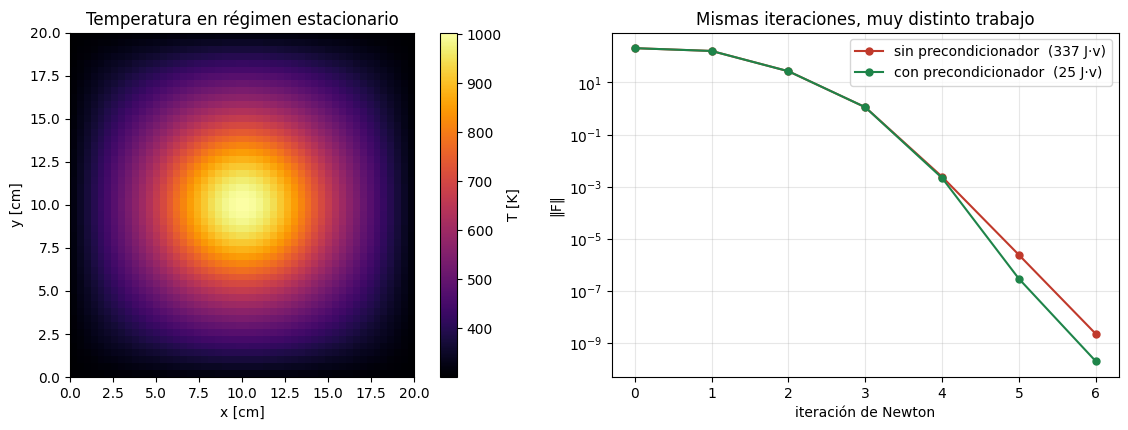

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4))

im = a1.imshow(T.T, origin="lower", cmap="inferno",
               extent=[0, L*100, 0, L*100], aspect="equal")
a1.set_xlabel("x [cm]"); a1.set_ylabel("y [cm]")
a1.set_title("Temperatura en régimen estacionario")
fig.colorbar(im, ax=a1, label="T [K]")

for etiqueta, color in [("sin precondicionador", "#c0392b"),
                        ("con precondicionador", "#1e8449")]:
    r = salidas[etiqueta][2]
    a2.semilogy(r, "o-", color=color, ms=5, label=f"{etiqueta}  ({salidas[etiqueta][1]['Jv']} J·v)")
a2.set_xlabel("iteración de Newton")
a2.set_ylabel("‖F‖")
a2.set_title("Mismas iteraciones, muy distinto trabajo")
a2.grid(alpha=.3); a2.legend()

plt.tight_layout(); plt.show()

Las dos corridas dan la misma solución y usan las mismas iteraciones de Newton, pero
una gasta un orden de magnitud más de productos `J·v` que la otra. Como cada producto
cuesta una evaluación de la función, esa es la diferencia que se paga en tiempo.

El Jacobiano de 6 250 000 entradas nunca se construyó.